# Stage 6d(plot) — SCM-vs-MESM fidelity, per scenario

Additional Major Point 4 asked for a *diagnostic of surrogate fidelity*: how well
the recalibrated SCM (`mode='MESM'`) reproduces MESM's own temperature response,
not just the NRMSE/R² summary `scripts/6d_scm_mesm_fidelity.py` already exports to
`data/SI_results/scm_mesm_fidelity/scm_mesm_fidelity_results.pkl`. That summary had
no companion figure — this notebook is it, one subplot per scenario, so the shape
of the fit (not just its NRMSE) is visible.

**Scope, matching Stage 6d exactly (see `REVISIONS.md`):** CO2-only
(`agents=['CO2']`), Tier 1 / Tier 2 / DECK / CS3. DAMIP/GeoMIP are excluded — no
MESM ground truth exists for them. The checkpoints used are the existing,
pre-Phase-0 MESM calibration (`checkpoints/co2/*_MESM.pkl`), read-only, per Stage
6d's own scope note — this notebook adds no new compute beyond one forward SCM
pass per scenario (cheap, CPU, no cluster).

**Reused, not reimplemented:** `build_eval_sets`, `scm_gmst_by_scenario`,
`mesm_global_truth_by_scenario` and `nrmse_r2` are imported directly from
`scripts/6d_scm_mesm_fidelity.py`, so every number plotted here is computed by the
exact same code that produced the numbers already reported for Additional Major
Point 4 — this notebook is a visualization of that result, not a second,
independently-computed one.

**X-axis convention** (stated explicitly since the underlying arrays are
0-indexed, not calendar-dated — see `extract_years_and_emis`):
- **Tier 1's `historical`** (the only historical panel kept, matching Stage 6d's
  own inclusion rule): calendar year, anchored at 1750 (274 years → 1750–2023).
- **Every other Tier 1 / Tier 2 scenario** (`H-ext`, `M`, `ML`, `L`, `VLLO-ext`,
  `VLHO`, `H-ext-OS`, `M-ext`, `ML-ext`, `L-ext`, `VLHO-ext`): calendar year,
  anchored at 2024 — the `opt_start_year` convention already used throughout
  `utils_plotting.py` for these same scenario families.
- **CS3** (`AA`, `CT`): calendar year, anchored at 2024 (2024–2150, 127 years) —
  matching the real-world timebound of MESM's own archived ground truth for these
  scenarios, not an idealized/simulation-year axis. **Caveat:** `AA`/`CT`'s own
  driving emissions (`data/CS3_outlook25/edaily.e5_*.fordata`) are a real,
  2006–2150-dated projection (MIT Global Change Outlook 2025), but MESM's archived
  truth for these scenarios goes through this codebase's existing, scenario-
  agnostic `target_crop_future=162` step (`utils_inverse.build_dataset_vector_targets`),
  which — confirmed by CS3's raw MESM archive sharing Tier 1's non-extension
  scenarios' exact raw length (289 rows) and 2024 anchor — lands MESM's truth at
  2024–2150, not 2006–2150. `nrmse_r2`'s front-truncation (`pred[:n]`) then pairs
  that against the *first* 127 years of the SCM's 145-year (2006–2150) run, i.e.
  2006–2132. The two curves in panels (o)/(p) are therefore offset by ~18 real
  years from each other; the x-axis here is labelled to match MESM ground truth
  (this codebase's calendar convention for every other real-world scenario), by
  explicit user decision, not because the SCM curve's own years were re-derived
  to match. NRMSE/R² are unaffected either way — both are computed by Stage 6d's
  unmodified `nrmse_r2` on the same array pairing as before.
- **DECK** (`1pctCO2`, `2xCO2`): **simulation year**, not calendar year. These are
  genuinely idealized experiments with no established calendar-year anchor in this
  codebase. Labelling them as calendar years would be a fabricated precision this
  notebook avoids.

In [1]:
import pickle
import importlib.util
from pathlib import Path

import numpy as np
import pandas as pd

import utils_plotting

PROJECT_ROOT = Path.cwd()
FIDELITY_PKL = Path("data/SI_results/scm_mesm_fidelity/scm_mesm_fidelity_results.pkl")

# scripts/6d_scm_mesm_fidelity.py's name starts with a digit, so it can't be
# imported with a normal `import` statement — load it as a module directly,
# matching the pattern already used for scripts/6i_fig6_ood_extension.py etc.
_spec = importlib.util.spec_from_file_location(
    "s6d_fidelity", PROJECT_ROOT / "scripts" / "6d_scm_mesm_fidelity.py"
)
s6d = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(s6d)

## 1. Run the recalibrated SCM forward, and pull the matching MESM truth

Both calls are Stage 6d's own functions, unmodified. This is the only compute
this notebook performs — a handful of forward SCM passes, CPU, well under a
minute.

In [2]:
eval_emis_sets, eval_targets_sets, lat_coords = s6d.build_eval_sets()

scm_gmst, mesm_truth = {}, {}
for set_name, emis_d in eval_emis_sets.items():
    targets_d = eval_targets_sets.get(set_name)
    if targets_d is None:
        print(f"[{set_name}] no MESM targets found, skipping")
        continue
    scm_gmst[set_name] = s6d.scm_gmst_by_scenario(emis_d)
    mesm_truth[set_name] = s6d.mesm_global_truth_by_scenario(emis_d, targets_d, lat_coords)
    print(f"[{set_name}] {sorted(scm_gmst[set_name])}")

[Tier 1] ['H-ext', 'L', 'M', 'ML', 'VLHO', 'VLLO-ext', 'historical']


[Tier 2] ['H-ext-OS', 'L-ext', 'M-ext', 'ML-ext', 'VLHO-ext', 'historical']


[CS3] ['AA', 'CT', 'historical']
[All] no MESM targets found, skipping


[DECK] ['1pctCO2', '2xCO2']


## 2. Build one panel per scenario

Same scenario inclusion rule as `6d_scm_mesm_fidelity.py`'s own `main()`: skip
`historical` everywhere except Tier 1 (Tier 1's `historical` is the only one with
an unambiguous 1750-anchored calendar mapping; Tier 2 and CS3 both carry their own,
differently-lengthed `historical` arrays that are never scored or plotted for this
reason). `nrmse_r2` truncates SCM/MESM to their shared length — the same arrays
are truncated here before plotting, so what's drawn matches exactly what's
scored.

In [3]:
CALENDAR_SETS = {"Tier 1", "Tier 2", "CS3"}  # 2024-anchored (or 1750 for `historical`)
SIM_YEAR_SETS = {"DECK"}                     # idealized experiments, no calendar anchor

panels = []
for set_name in ["Tier 1", "Tier 2", "DECK", "CS3"]:
    for scen, scm_arr in scm_gmst[set_name].items():
        if scen == "historical" and set_name != "Tier 1":
            continue  # matches Stage 6d's own scoring exclusion

        truth_arr = mesm_truth[set_name].get(scen)
        if truth_arr is None:
            print(f"[{set_name}/{scen}] no MESM truth, skipping")
            continue

        nrmse, r2, n = s6d.nrmse_r2(np.asarray(scm_arr), np.asarray(truth_arr))

        if set_name in CALENDAR_SETS:
            start = 1750 if scen == "historical" else 2024
            x = np.arange(start, start + n)
            xlabel = "Year"
        else:
            x = np.arange(n)
            xlabel = "Simulation year"

        panels.append(dict(
            set_name=set_name, scenario=scen, x=x, xlabel=xlabel,
            scm=np.asarray(scm_arr)[:n], mesm=np.asarray(truth_arr)[:n],
            nrmse=nrmse, r2=r2,
        ))

print(f"{len(panels)} panels")

16 panels


## 3. Cross-check against the published Additional-4 numbers

`scripts/6d_scm_mesm_fidelity.py` already wrote
`data/SI_results/scm_mesm_fidelity/scm_mesm_fidelity_results.pkl`. Since this
notebook calls the exact same functions, every per-scenario NRMSE/R² here should
match that file to full precision — this cell is a hard check that nothing drifted
(e.g. a checkpoint regenerated since Stage 6d last ran).

In [4]:
with open(FIDELITY_PKL, "rb") as f:
    published = pickle.load(f)["per_scenario_set"]

mismatches = []
for p in panels:
    ref = published.get(p["set_name"], {}).get(p["scenario"])
    if ref is None:
        mismatches.append((p["set_name"], p["scenario"], "not in published pickle"))
        continue
    if not (np.isclose(ref["nrmse"], p["nrmse"], atol=1e-6)
            and np.isclose(ref["r2"], p["r2"], atol=1e-6)):
        mismatches.append((p["set_name"], p["scenario"],
                            f"published nrmse={ref['nrmse']:.6f} r2={ref['r2']:.6f} "
                            f"vs. here nrmse={p['nrmse']:.6f} r2={p['r2']:.6f}"))

if mismatches:
    print("MISMATCHES (checkpoints likely changed since Stage 6d last ran):")
    for m in mismatches:
        print(" ", m)
else:
    print(f"All {len(panels)} panels match the published Additional-4 numbers exactly.")

All 16 panels match the published Additional-4 numbers exactly.


## 4. The figure

One subplot per scenario: MESM's own area-weighted global-mean temperature
(solid black, "MESM global average") against the MESM-calibrated SCM's forward
projection (dashed, "MESM-calibrated SCM") — see the legend at the bottom of the
figure. Panels carry no title; each is labelled (a), (b), ... plus its scenario
name, matching Figure 3's boxed-annotation convention, since the NRMSE/R² values
are reported in the table in Section 5 instead of in-panel. All panels share one
y-axis range (the min/max of every trajectory drawn), so warming magnitudes are
directly comparable scenario-to-scenario.

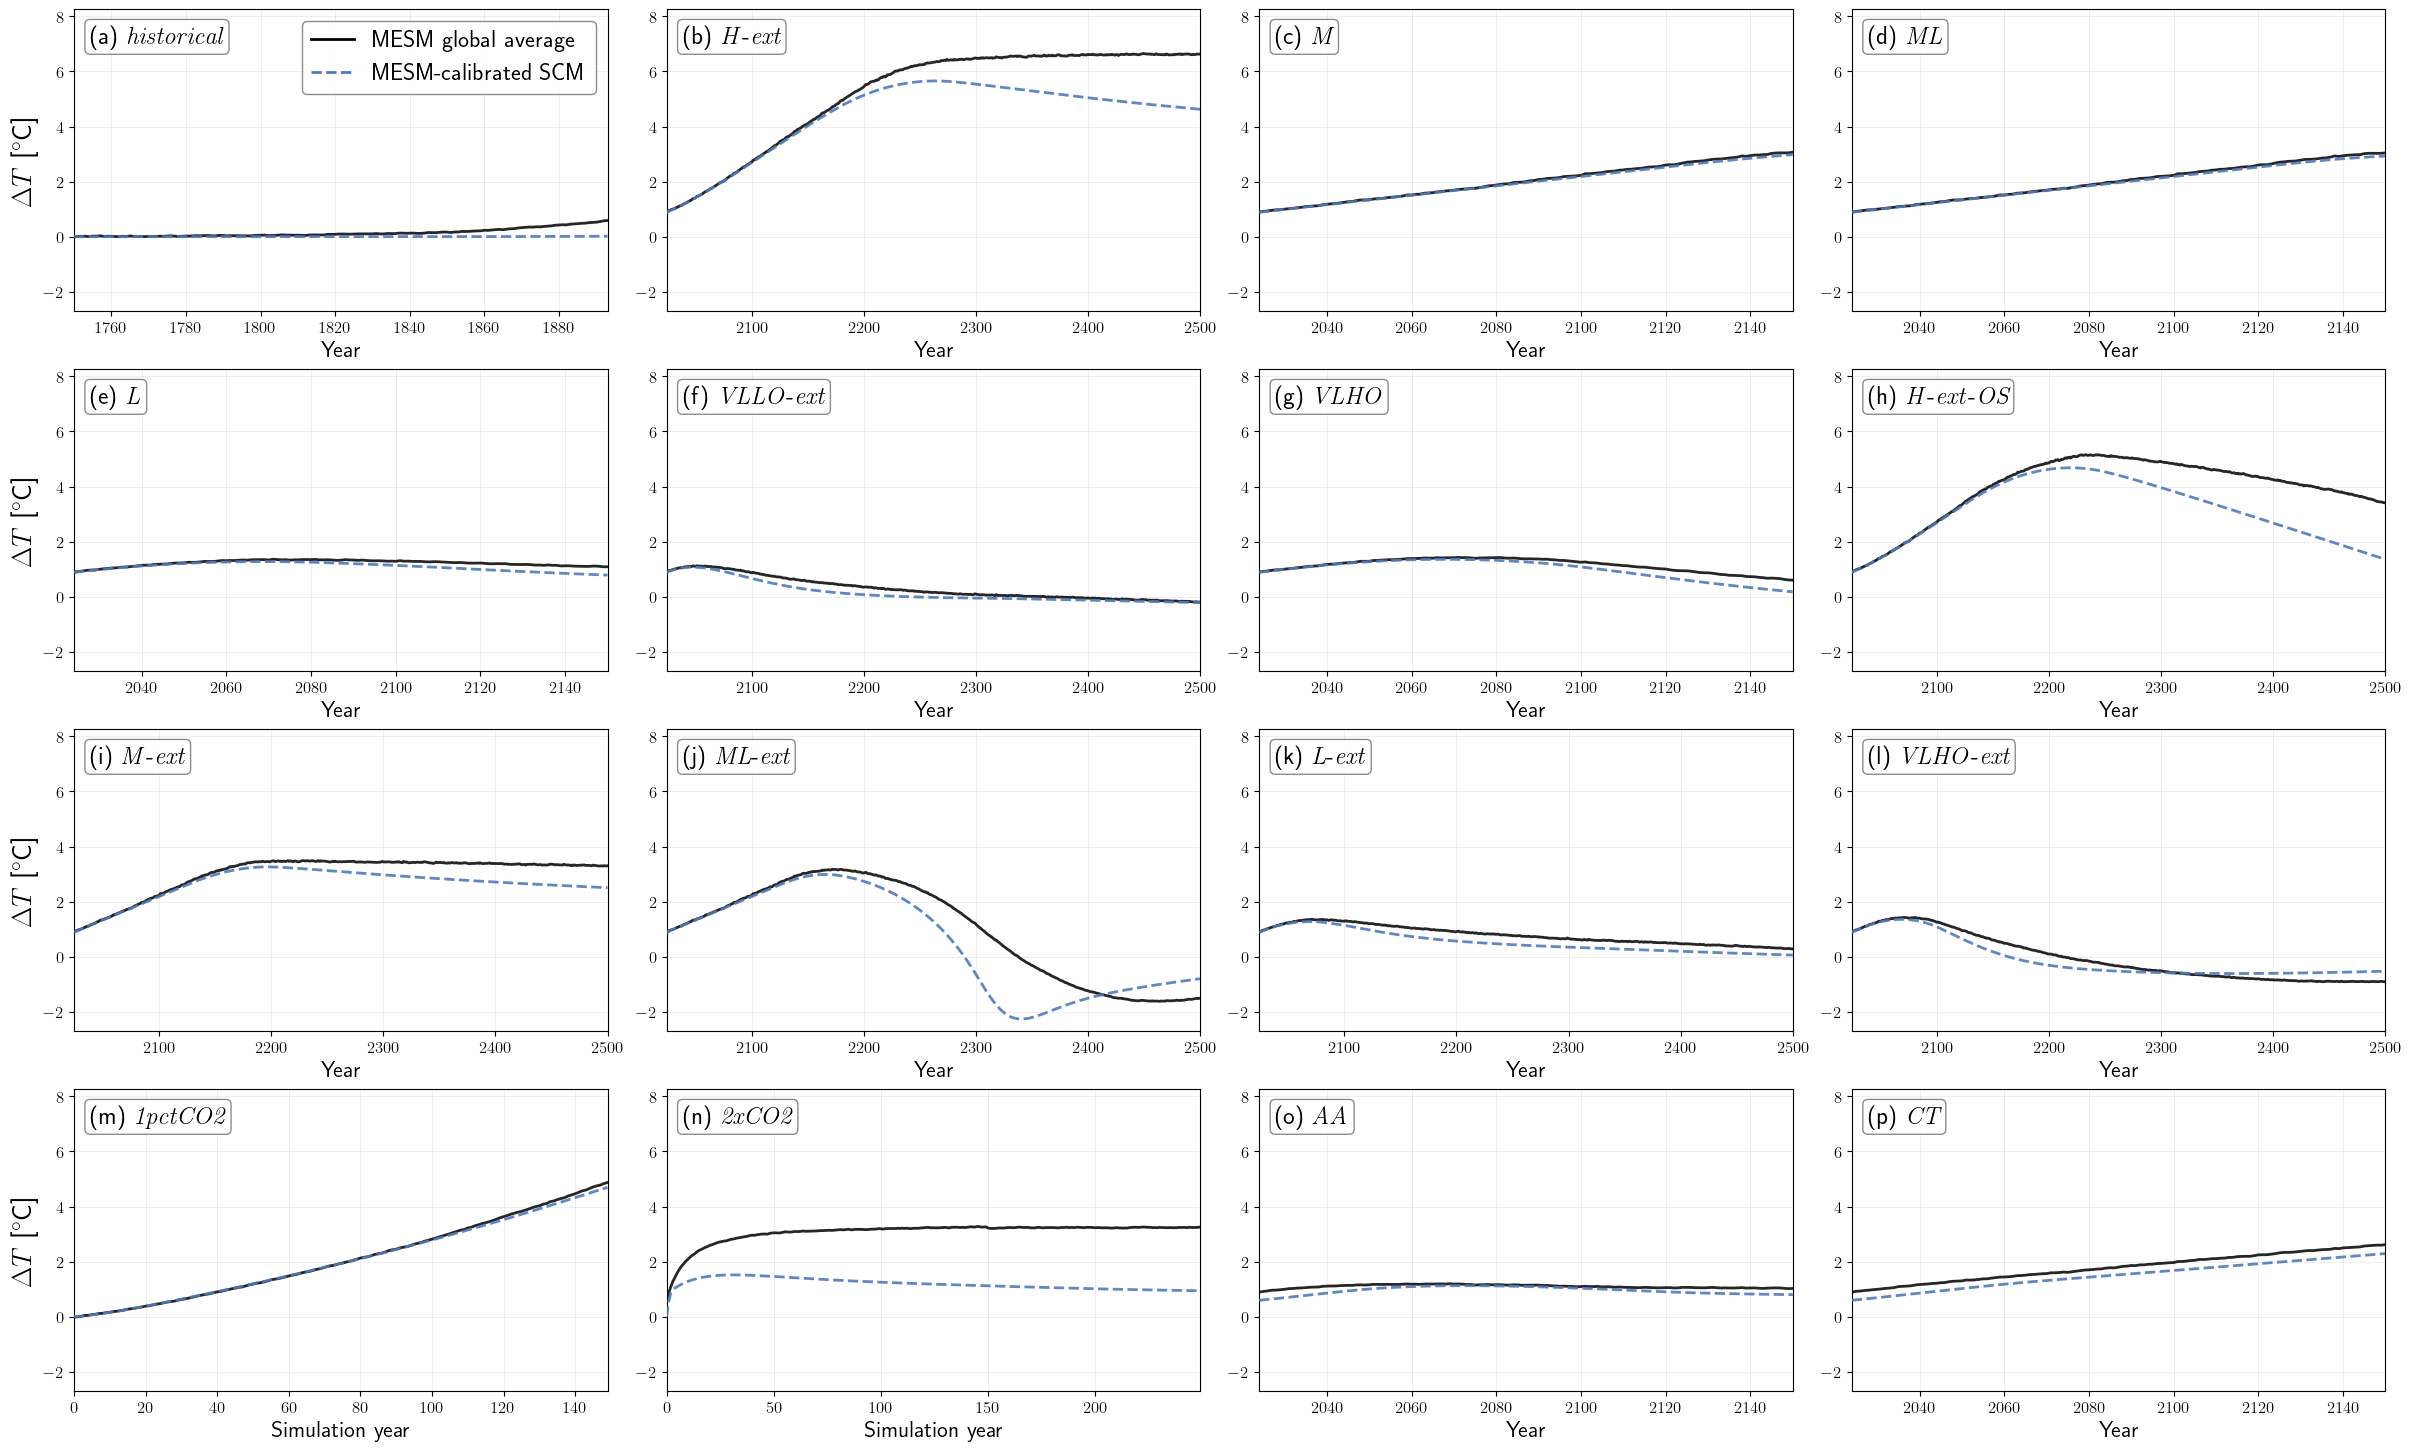

In [5]:
fig, axes = utils_plotting.plot_scm_mesm_fidelity_grid(
    panels, ncols=4, save="fig_scm_mesm_fidelity_grid",
)

**A pattern visible across most panels, not just in the summary numbers:**
after each scenario's emissions peak, the recalibrated SCM (dashed) decays faster
than MESM (solid) holds its warming — most clearly in `H-ext`, `VLLO-ext`, `VLHO`,
`M-ext`, `ML-ext`, `L-ext`, `VLHO-ext`, and `2xCO2`. The SCM's initial rise tracks
MESM closely in nearly every panel; the miss is specifically in the post-peak
regime, where MESM's own thermal inertia keeps temperatures elevated longer than
the recalibrated three-box EBM does. This is the same qualitative failure mode
Stage 6i/6j found independently for the emulator on `esm-pi-CO2pulse` (the
zero-emissions-commitment signature) — here it appears one level upstream, in the
SCM surrogate itself, on scenarios where emissions actively decline rather than
merely go to zero. Worth stating explicitly if Additional Major Point 4's response
leans on this diagnostic: the surrogate's fidelity gap is not random noise, it is
concentrated in the declining-emissions tail.

## 5. Summary table

Per-scenario NRMSE/R², plus the per-scenario-set means already reported for
Additional Major Point 4. Section 5b turns the NRMSE column of this same table
into a LaTeX table, in the same style as the existing SI numerical-results
tables in `supplement_revision.tex` (e.g. `tab:supp_num_fig35`).

In [6]:
df = pd.DataFrame([{k: p[k] for k in ("set_name", "scenario", "nrmse", "r2")} for p in panels])
df = df.sort_values(["set_name", "scenario"]).reset_index(drop=True)

means = df.groupby("set_name")[["nrmse", "r2"]].mean().reset_index()
means["scenario"] = "— mean —"

summary = pd.concat([df, means], ignore_index=True).sort_values(
    ["set_name", "scenario"], key=lambda s: s.map(lambda v: (v != "— mean —", v))
)
overall = pd.DataFrame([{"set_name": "ALL", "scenario": "— overall mean —",
                          "nrmse": df["nrmse"].mean(), "r2": df["r2"].mean()}])
pd.concat([summary, overall], ignore_index=True)

,set_name,scenario,nrmse,r2
0,CS3,— mean —,0.127340,-2.609125
1,CS3,AA,0.140933,-5.855491
2,CS3,CT,0.113746,0.637242
3,DECK,— mean —,0.300788,-10.384804
4,DECK,1pctCO2,0.013961,0.997765
5,DECK,2xCO2,0.587616,-21.767373
6,Tier 1,— mean —,0.139278,0.241683
7,Tier 1,H-ext,0.158324,0.670121
8,Tier 1,L,0.119978,-1.163117
9,Tier 1,M,0.017729,0.992968


## 5b. LaTeX table — NRMSE by scenario

Same per-scenario NRMSE values as the table above (and the same numbers behind
each panel in Section 4, now that panels no longer print them), formatted as a
LaTeX table matching the existing SI numerical-results tables' style (e.g.
`tab:supp_num_fig35`: `\hline` under the header, `\cline` between scenario-set
groups, `\renewcommand{\arraystretch}{1.5}`). Each set's row group ends with its
own mean, reusing the `means` DataFrame already computed above rather than
recomputing it.

In [7]:
def _latex_escape(s: str) -> str:
    return s.replace("_", r"\_")

SET_ORDER = ["Tier 1", "Tier 2", "DECK", "CS3"]

tex_lines = [
    r"\begin{table}[b!]",
    r"    \centering",
    r"    \caption{Numerical results for the \gls{scm}--\gls{emic} fidelity diagnostic "
    r"(Additional Major Point 4). \gls{nrmse} is reported for the MESM-calibrated "
    r"\gls{scm} (\texttt{mode=`MESM'}) against MESM's own area-weighted global-mean "
    r"temperature, for each CO$_2$-only scenario (see Table~\ref{tab:supp_scenarios} "
    r"for scenario descriptions). \textit{Mean} rows give the unweighted average NRMSE "
    r"within each scenario set.}",
    r"    \renewcommand{\arraystretch}{1.5}",
    r"    \begin{tabular}{l l r}",
    r"        \textbf{Scenario Set} & \textbf{Scenario} & \textbf{NRMSE}\\",
    r"        \hline",
]
for gi, set_name in enumerate(SET_ORDER):
    sub = df[df["set_name"] == set_name].sort_values("scenario").reset_index(drop=True)
    for i, row in sub.iterrows():
        set_col = set_name if i == 0 else ""
        tex_lines.append(f"        {set_col} & {_latex_escape(row['scenario'])} & {row['nrmse']:.3f} \\\\")
    mean_val = float(means.loc[means["set_name"] == set_name, "nrmse"].iloc[0])
    tex_lines.append(rf"        & \textit{{mean}} & {mean_val:.3f} \\")
    if gi < len(SET_ORDER) - 1:
        tex_lines.append(r"        \cline{1-3}")
tex_lines += [
    r"    \end{tabular}",
    r"    \label{tab:supp_scm_mesm_fidelity}",
    r"\end{table}",
]
latex_table = "\n".join(tex_lines)
print(latex_table)

TABLE_TEX_PATH = FIDELITY_PKL.parent / "scm_mesm_fidelity_table.tex"
TABLE_TEX_PATH.write_text(latex_table + "\n")
print(f"\nwrote {TABLE_TEX_PATH}")

\begin{table}[b!]
    \centering
    \caption{Numerical results for the \gls{scm}--\gls{emic} fidelity diagnostic (Additional Major Point 4). \gls{nrmse} is reported for the MESM-calibrated \gls{scm} (\texttt{mode=`MESM'}) against MESM's own area-weighted global-mean temperature, for each CO$_2$-only scenario (see Table~\ref{tab:supp_scenarios} for scenario descriptions). \textit{Mean} rows give the unweighted average NRMSE within each scenario set.}
    \renewcommand{\arraystretch}{1.5}
    \begin{tabular}{l l r}
        \textbf{Scenario Set} & \textbf{Scenario} & \textbf{NRMSE}\\
        \hline
        Tier 1 & H-ext & 0.158 \\
         & L & 0.120 \\
         & M & 0.018 \\
         & ML & 0.019 \\
         & VLHO & 0.153 \\
         & VLLO-ext & 0.157 \\
         & historical & 0.350 \\
        & \textit{mean} & 0.139 \\
        \cline{1-3}
        Tier 2 & H-ext-OS & 0.208 \\
         & L-ext & 0.198 \\
         & M-ext & 0.132 \\
         & ML-ext & 0.296 \\
         & VLHO-ext &

## Caveats to carry into the text

- **DECK's `2xCO2` (panel n, NRMSE = 0.588, R² = −21.8) is the single
  worst-fitting scenario by NRMSE, and the dominant driver of DECK's poor mean
  R².** `1pctCO2` (panel m) fits almost perfectly (NRMSE = 0.014, R² = 0.998);
  the abrupt step-change experiment does not. Both use the same idealized,
  no-historical convention, so this reads as a real limitation of the 3-box
  EBM under an abrupt forcing step, not a bug — see panel (n) for the shape of
  the miss.
- **Ranked by NRMSE rather than R², Tier 1's `historical` panel (a) is the
  second-worst fit (NRMSE = 0.350)** — despite a middling R² (−0.81), well
  short of DECK/CS3's most negative values. `historical`'s own warming signal
  is small in absolute magnitude (peak ≈1.3°C over 1750–2023), so NRMSE's
  max-abs-truth normalization amplifies the same absolute miss that a
  larger-magnitude scenario would mostly absorb — worth flagging since the
  R²-ranked caveats above would otherwise miss it.
- **Tier 2's `ML-ext` (panel j, NRMSE = 0.296) is the worst-fitting
  non-idealized, non-historical scenario** — see panel for the post-peak
  shape of the miss (Section 4's declining-emissions-tail pattern).
- **CS3's `AA` panel (o) (R² = −5.86, NRMSE = 0.141) is a large R² miss
  despite a mid-pack NRMSE** — visible directly in its subplot, not just in
  the summary number.
- **DECK's x-axis is simulation year, not calendar year** — `1pctCO2`/`2xCO2`
  are genuinely idealized experiments with no established calendar-year anchor
  in this codebase (see the note in Section 1).
- **CS3's `AA`/`CT` panels (o)/(p) are calendar-labelled 2024–2150 to match
  MESM ground truth, but the plotted SCM trace is really 2006–2132** — an
  ~18-year offset baked into the existing (unmodified) Stage 6d scoring
  pipeline's fixed historical-prefix crop, not something introduced by this
  notebook. See the full explanation in Section 1's X-axis convention note
  before citing panel shape (not just NRMSE) for these two scenarios.
- **Fidelity is decent in NRMSE but the R² sign is mostly negative** across DECK
  and CS3 — visible here as MESM's own year-to-year variability being larger than
  the SCM's smooth response, not as a systematic bias (see the panels).